# HIV-1 Co-receptor Tropism Classification Using FCGRCollection

In [32]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
from Bio import SeqIO

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

from kaospy import FCGRCollection
from kaospy.matrix.api import Matrix

blue="#045a8d"
pink="#c51b7d"
green="#4d9221"

<br>

### Loading HIV-1 V3 Sequences

In [2]:
data_path = Path("./data/tropism")

x4_file = data_path / "X4.fasta"
r5_file = data_path / "R5.fasta"

In [3]:
def load_fasta(path):
    sequences = {}

    for record in SeqIO.parse(path, "fasta"):
        sequences[record.id] = str(record.seq)

    return sequences


x4 = load_fasta(x4_file)

r5 = load_fasta(r5_file)

<br>

### Creating FCGRCollections

In [8]:
x4_collection = FCGRCollection(
    x4,
    resolution=20,
    symbols="AMINO"
)

r5_collection = FCGRCollection(
    r5,
    resolution=20,
    symbols="AMINO"
    
)

## Statistical FCGR Summaries

In [9]:
def collection_statistics(collection):
    return {
        "Mean": collection.mean(),
        "Median": collection.median(),
        "Variance": collection.variance(),
        "Standard deviation": collection.std(),
    }

In [10]:
x4_matrices = collection_statistics(x4_collection)
r5_matrices = collection_statistics(r5_collection)

x4_mean = x4_matrices["Mean"]
r5_mean = r5_matrices["Mean"]

mean_difference = x4_mean - r5_mean

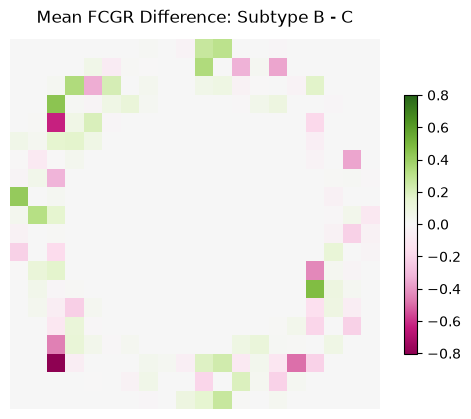

In [11]:
fig, ax, im = mean_difference.plot(
    cmap="PiYG",
    symmetric=True,
    colorbar=True,
    title="Mean FCGR Difference"
)

plt.show()

<br>

## Significant FCGR Features
<br>

Preparing stacked NumPy arrays for further analysis:


In [13]:
X4_matrices = x4_collection.stacked_matrix()
R5_matrices = r5_collection.stacked_matrix()

<br>

Pixel-wise statistical comparison of FCGR matrices using the Mann–Whitney U test with Bonferroni correction for multiple testing.

In [21]:
p_values = []

for i in range(x4_collection.resolution):
    for j in range(x4_collection.resolution):

        _, p = mannwhitneyu(
            X4_matrices[:, i, j],
            R5_matrices[:, i, j],
            alternative="two-sided"
        )

        p_values.append(p)

p_values_corrected = multipletests(
    p_values,
    method="bonferroni"
)[1]

p_value_matrix = Matrix(
    p_values_corrected.reshape(
        x4_collection.resolution,
        x4_collection.resolution
    )
)


<br>
Statistical significance (-log10 corrected p-values)

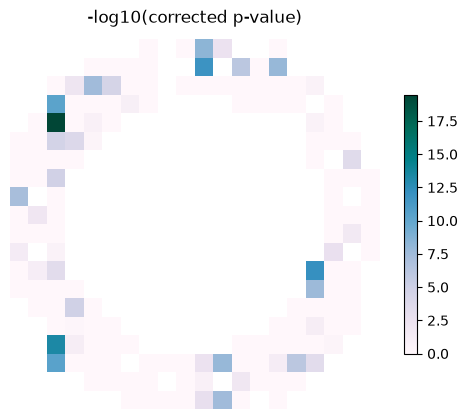

In [24]:
resolution = x4_collection.resolution


p_value_matrix = Matrix(
    -np.log10(
        p_values_corrected.reshape(
            resolution,
            resolution
        )
    )
)

fig, ax, im = p_value_matrix.plot(
    cmap="PuBuGn",
    colorbar=True,
    title="-log10(corrected p-value)"
)

plt.show()

<br>

Significant FCGR positions

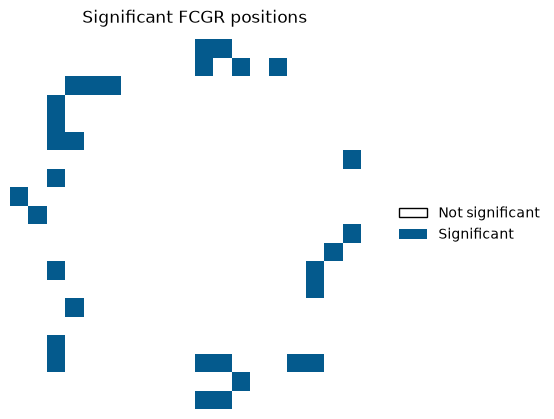

In [29]:
significant = p_values_corrected < 0.05


significant_matrix = Matrix(
    significant.astype(float).reshape(
        resolution,
        resolution
    )
)

fig, ax, im = significant_matrix.plot(
    cmap=ListedColormap(["white", blue]),
    colorbar=False,
    title="Significant FCGR positions"
)

legend_elements = [
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Not significant"
    ),
    Patch(
        facecolor=blue,
        label="Significant"
    )
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()

<br>

### Clustering

PCA projection of flattened FCGR representations, where each point represents one HIV-1 V3-loop sample.

In [30]:
X4_vectors = x4_collection.feature_matrix()

R5_vectors = r5_collection.feature_matrix()


X = np.concatenate(
    [
        X4_vectors,
        R5_vectors
    ]
)


labels = np.array(
    ["X4"] * len(X4_vectors)
    +
    ["R5"] * len(R5_vectors)
)


pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X
)

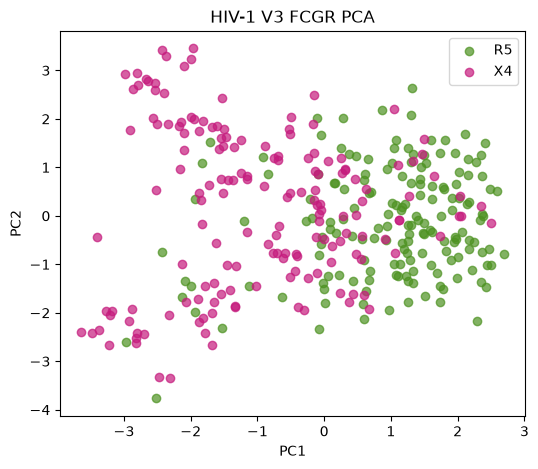

In [33]:
plt.figure(figsize=(6, 5))

for label in np.unique(labels):
    mask = labels == label

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label,
        color=pink if label == "X4" else green,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA")
plt.legend()
plt.show()

<br>

## Multi-Layer Perceptron
<br>
No clear linear separation is observed in PCA, motivating MLP classification on FCGR features.

<br>

### Train-Test Split
<br>
Stratified train-test split preserving class distribution.

In [7]:
random_state=3
test_size=0.2

x4_train_items, x4_test_items = train_test_split(
    list(x4.items()),
    test_size = test_size,
    random_state = random_state
)

r5_train_items, r5_test_items = train_test_split(
    list(r5.items()),
    test_size = test_size,
    random_state = random_state
)

x4_train = dict(x4_train_items)
x4_test = dict(x4_test_items)

r5_train = dict(r5_train_items)
r5_test = dict(r5_test_items)

<br>

### FCGR Encoding

In [8]:
resolution=100
s="AMINO"

x4_train_collection = FCGRCollection(
    x4_train,
    resolution=resolution,
    symbols=s
)

r5_train_collection = FCGRCollection(
    r5_train,
    resolution=resolution,
    symbols=s
)


x4_test_collection = FCGRCollection(
    x4_test,
    resolution=resolution,
    symbols=s
)

r5_test_collection = FCGRCollection(
    r5_test,
    resolution=resolution,
    symbols=s
)

<br>

### Preprocessing data
<br>

In [9]:
x4_train_features = x4_train_collection.feature_matrix()
r5_train_features = r5_train_collection.feature_matrix()

x4_test_features = x4_test_collection.feature_matrix()
r5_test_features = r5_test_collection.feature_matrix()


X_train = np.vstack([
    x4_train_features,
    r5_train_features
])

X_test = np.vstack([
    x4_test_features,
    r5_test_features
])


y_train = np.array(
    [0] * len(x4_train_features)
    + [1] * len(r5_train_features)
)

y_test = np.array(
    [0] * len(x4_test_features)
    + [1] * len(r5_test_features)
)

<br>

### Impact of Feature Scaling

In [10]:


def evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    hidden_layer_sizes=(20,),
    seed=3,
    scale=False
):

    if scale:
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        max_iter=1000,
        random_state=seed
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob)
    }

In [11]:
unscaled = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    scale=False
)

scaled = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    scale=True
)

In [12]:
print("Without scaling:", unscaled)
print("With scaling:", scaled)

Without scaling: {'accuracy': 0.8823529411764706, 'auc': 0.9143598615916955}
With scaling: {'accuracy': 0.8970588235294118, 'auc': 0.9160899653979238}


<br>

### Impact of Resolution

In [13]:
def evaluate_resolution(
    x4_sequences,
    r5_sequences,
    resolution,
    hidden_layer_sizes=(20,),
    seed=3
):


    s="AMINO"
    x4_collection = FCGRCollection(
        x4_sequences,
        resolution=resolution,
        symbols=s
    )

    r5_collection = FCGRCollection(
        r5_sequences,
        resolution=resolution,
        symbols=s
    )

    X_x4 = np.array([
        fcgr.matrix.flatten()
        for fcgr in x4_collection.fcgrs.values()
    ])

    X_r5 = np.array([
        fcgr.matrix.flatten()
        for fcgr in r5_collection.fcgrs.values()
    ])

    X = np.vstack([
        X_x4,
        X_r5
    ])

    y = np.array(
        [0] * len(X_x4)
        + [1] * len(X_r5)
    )

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        max_iter=1000,
        random_state=seed
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    return scores

In [14]:
resolutions = [20, 50, 100, 150,200]

results = {}

for res in resolutions:
    results[res] = evaluate_resolution(
        x4_train,
        r5_train,
        resolution=res
    )

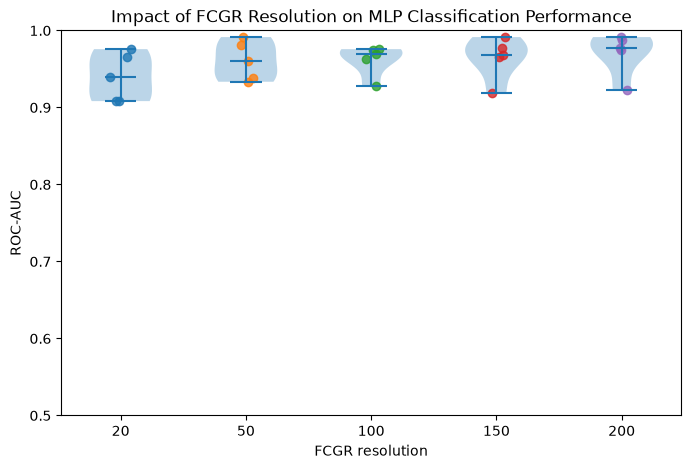

In [15]:
data = [
    results[20],
    results[50],
    results[100],
    results[150],
    results[200]
]

labels = [
    20,
    50,
    100,
    150,
    200
]


plt.figure(figsize=(8, 5))

parts = plt.violinplot(
    data,
    positions=np.arange(len(labels)) + 1,
    showmeans=False,
    showmedians=True
)


for i, values in enumerate(data):
    x = np.random.normal(
        i + 1,
        0.04,
        size=len(values)
    )
    
    plt.scatter(
        x,
        values,
        alpha=0.8
    )


plt.xticks(
    np.arange(len(labels)) + 1,
    labels
)

plt.xlabel("FCGR resolution")
plt.ylabel("ROC-AUC")

plt.ylim(
    0.5,
    1.0
)

plt.title(
    "Impact of FCGR Resolution on MLP Classification Performance"
)

plt.show()

<br >

### Selecting Optimal Resolution
<br>

In [16]:
mean_scores = {
    resolution: np.mean(scores)
    for resolution, scores in results.items()
}

best_resolution = max(
    mean_scores,
    key=mean_scores.get
)

print(
    "Best resolution:",
    best_resolution
)

print(
    "Mean AUC:",
    mean_scores[best_resolution]
)

Best resolution: 200
Mean AUC: 0.9706552706552707


<br>

### Create FCGR collections with the best resolution


In [17]:

best_x4_collection = FCGRCollection(
    x4_train,
    resolution=best_resolution,
    symbols="AMINO"
)

best_r5_collection = FCGRCollection(
    r5_train,
    resolution=best_resolution,
    symbols="AMINO"
)

best_x4_test_collection = FCGRCollection(
    x4_test,
    resolution=best_resolution,
    symbols="AMINO"
)

best_r5_test_collection = FCGRCollection(
    r5_test,
    resolution=best_resolution,
    symbols="AMINO"
)



<br>

### Convert FCGR collections into feature matrices

In [18]:

X_train_best = np.vstack([
    best_x4_collection.feature_matrix(),
    best_r5_collection.feature_matrix()
])

X_test_best = np.vstack([
    best_x4_test_collection.feature_matrix(),
    best_r5_test_collection.feature_matrix()
])

<br>

### Train labels

In [19]:
# Labels
y_train_best = np.array(
    [0] * len(best_x4_collection)
    + [1] * len(best_r5_collection)
)

y_test_best = np.array(
    [0] * len(best_x4_test_collection)
    + [1] * len(best_r5_test_collection)
)





<br>

### Train final model

In [20]:
seed = 3

final_model = MLPClassifier(
    hidden_layer_sizes=(20,),
    max_iter=1000,
    random_state=seed
)

final_model.fit(
    X_train_best,
    y_train_best
)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",3
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


<br>

### Evaluate on holdout test set

In [21]:
y_prob_test = final_model.predict_proba(
    X_test_best
)[:, 1]

y_pred_test = final_model.predict(
    X_test_best
)


print("Best resolution:", best_resolution)
print("Holdout ROC-AUC:", roc_auc_score(y_test_best, y_prob_test))
print("Holdout accuracy:", accuracy_score(y_test_best, y_pred_test))
print(confusion_matrix(y_test_best, y_pred_test))

Best resolution: 200
Holdout ROC-AUC: 0.9463667820069204
Holdout accuracy: 0.8970588235294118
[[27  7]
 [ 0 34]]


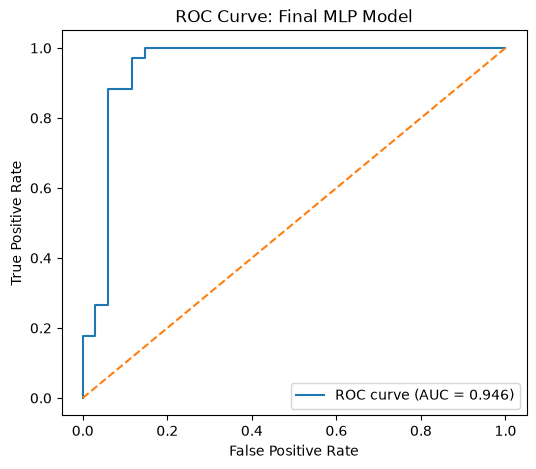

In [24]:


fpr, tpr, thresholds = roc_curve(
    y_test_best,
    y_prob_test
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Final MLP Model")
plt.legend()

plt.show()